In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd
import cv2
import os

#          Load data folders and files

In [2]:
cats_folder_path ='/content/drive/MyDrive/CVPR_practice/animal_dataset/cat/'
dogs_folder_path ='/content/drive/MyDrive/CVPR_practice/animal_dataset/dog/'
pandas_folder_path ='/content/drive/MyDrive/CVPR_practice/animal_dataset/panda/'

all_cats = os.listdir(cats_folder_path)
all_dogs = os.listdir(dogs_folder_path)
all_pandas = os.listdir(pandas_folder_path)


# Load images from files and reshape

In [3]:
data_dictionary ={'cat':cats_folder_path,
                  'dog':dogs_folder_path,
                  'panda':pandas_folder_path
                 }

data = []
lebels =[]
shape =[]

for key, value in data_dictionary.items():

  #file path based on category
  for i in range(100):
    if key == 'cat':
      img_path = os.path.join(value, all_cats[i])
    elif key == 'dog':
      img_path = os.path.join(value, all_dogs[i])
    elif key == 'panda':
      img_path = os.path.join(value, all_pandas[i])

    #Read image using file path
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    #reshpae the image(32,32)
    resize_img = cv2.resize(img, (32,32))
    data.append(resize_img)
    lebels.append(key)
    shape.append(resize_img.shape)


#Vizualize 9 image randomly

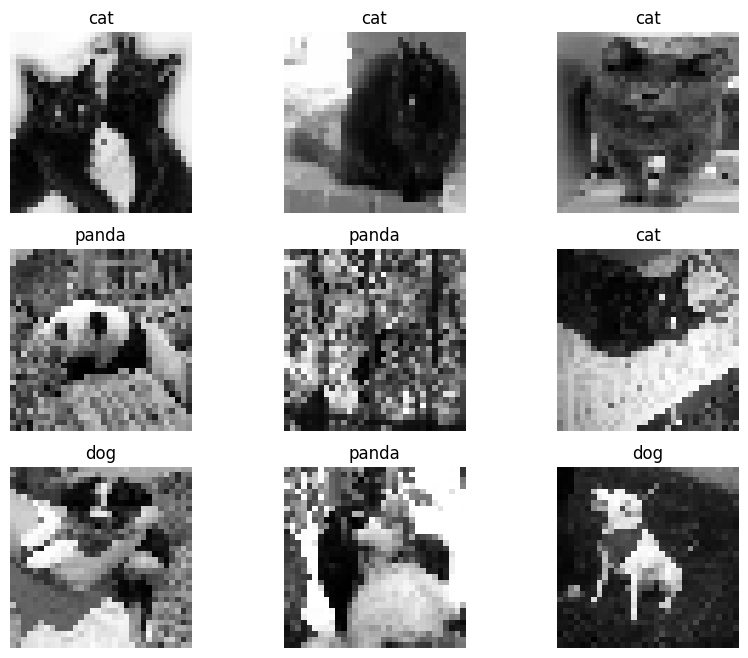

In [4]:
# Pick 9 random indices from dataset
random_9 = random.sample(range(0,299), 9)

#ploting images with lebels
plt.figure(figsize=(10,8))
i=0
for idx in random_9:
    i+=1
    plt.subplot(3,3,i)
    plt.imshow(data[idx], cmap='gray')
    plt.title(lebels[idx])
    plt.axis('off')

plt.show()

# Shape of the dataSet

In [5]:
data_array =np.array(data)
data_array.shape

print(f"Shape: {data_array.shape}")

Shape: (300, 32, 32)


# Zip and Shuffle

In [6]:
#binding images with their actual lebel
all_data = list(zip(data, lebels))
random.shuffle(all_data)



# Check image and lebels

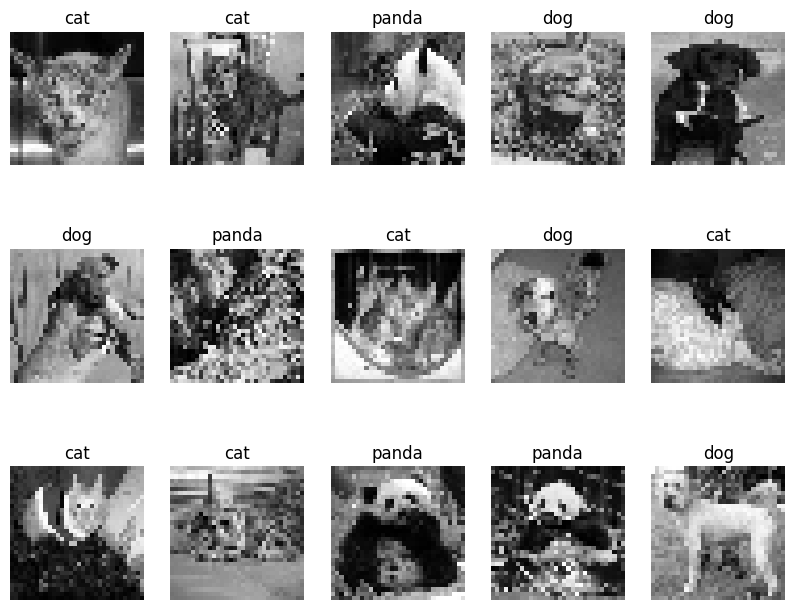

In [7]:
plt.figure(figsize=(10,8))
i=0
for idx in (random.sample(range(0,299),15)):
    i+=1
    plt.subplot(3,5,i)
    plt.imshow(all_data[idx][0], cmap='gray') #([index][0->data, 1->lebels])
    plt.title(all_data[idx][1])
    plt.axis('off')

plt.show()


# 5 Fold

In [8]:
#len(all_data)

fold_size = len(all_data) // 5  #60
#print(fold_size)
fold_1 = all_data[0:fold_size] #0-59
fold_2 = all_data[fold_size:2*fold_size] #60-119
fold_3 = all_data[2*fold_size:3*fold_size]
fold_4 = all_data[3*fold_size:4*fold_size]
fold_5 = all_data[4*fold_size:5*fold_size]
fold_data = [fold_1, fold_2, fold_3, fold_4, fold_5]

# Distance calculation

In [9]:
#Euclidean
def euclidean_distance(x, y):
    return np.sqrt(np.sum((x - y)**2))

#Manhattan
def manhattan_distance(x, y):
    return np.sum(np.abs(x - y))

# Voting or counting for Nearest neighbour value

In [10]:
def nearest_neighbor(x):
    categories =['cat', 'panda', 'dog']
    counts=[]
    for catagory in categories :
        count=0
        for i in range(len(x)):
            if(catagory == x[i]):
                count += 1
        counts.append([count, catagory])
    counts.sort(reverse=True)
    return counts[0][1]

# Training and Testing

In [11]:
num_neighbour = 5 #k value

euclidean_accuracy_folds = []
euclidean_loss_folds = []
manhattan_accuracy_folds = []
manhattan_loss_folds = []

first_images_info = []
pred_1st=''


for i in range(5):
    x_train_sample=[]
    x_test_sample=[]
    x_test_sample=fold_data[i]

    for j in range(5):
        if(j != i):
            x_train_sample.extend(fold_data[j])

    test_image_1st = x_test_sample[0][0]        #([index][0->data, 1->lebels])
    test_label_1st = x_test_sample[0][1]

    euclidean_correct_predicted = 0
    manhattan_correct_predicted =0
    t=0

    for test_image, test_label in x_test_sample:
        t+=1
        euclidean_dist=[]
        manhattan_dist = []

        for train_image, train_label in x_train_sample:

            euc_dist = euclidean_distance(train_image, test_image)
            euclidean_dist.append([euc_dist, train_label])

            man_dist = manhattan_distance(train_image, test_image)
            manhattan_dist.append([man_dist, train_label])

        euclidean_dist.sort(reverse=True)
        manhattan_dist.sort(reverse=True)

        euc_labels =[euclidean_dist[i][1] for i in range(num_neighbour)]

        pred = nearest_neighbor(euc_labels)
        if t==1:
            first_images_info.append((test_image_1st, test_label_1st, pred))
        else:
            t =t
        if pred == test_label :
            euclidean_correct_predicted +=1

        man_labels =[manhattan_dist[i][1] for i in range(num_neighbour)]
        pred = nearest_neighbor(man_labels)
        if pred == test_label :
            manhattan_correct_predicted +=1

#calculate accuracy and loss
    euclidean_accuracy = euclidean_correct_predicted/len(x_test_sample)
    euclidean_accuracy_folds.append(euclidean_accuracy)
    euclidean_loss = (1-euclidean_accuracy) * len(x_test_sample)
    euclidean_loss_folds.append(euclidean_loss)

 #print fold based accuracy, loss

    print(f'                   Fold {i+1} ')
    print('     Euclidean')
    print(f'Accuracy: {euclidean_accuracy*100:.2f}%')
    print(f'Loss: {euclidean_loss}')

    manhattan_accuracy = manhattan_correct_predicted / len(x_test_sample)
    manhattan_accuracy_folds.append(manhattan_accuracy)
    manhattan_loss = (1 - manhattan_accuracy)*len(x_test_sample)
    manhattan_loss_folds.append(manhattan_loss)
    print('     Manhattan')
    print(f'Accuracy: {manhattan_accuracy*100:.2f}%')
    print(f'Loss: {manhattan_loss}')

                   Fold 1 
     Euclidean
Accuracy: 23.33%
Loss: 46.0
     Manhattan
Accuracy: 41.67%
Loss: 34.99999999999999
                   Fold 2 
     Euclidean
Accuracy: 30.00%
Loss: 42.0
     Manhattan
Accuracy: 36.67%
Loss: 38.0
                   Fold 3 
     Euclidean
Accuracy: 33.33%
Loss: 40.00000000000001
     Manhattan
Accuracy: 45.00%
Loss: 33.0
                   Fold 4 
     Euclidean
Accuracy: 30.00%
Loss: 42.0
     Manhattan
Accuracy: 45.00%
Loss: 33.0
                   Fold 5 
     Euclidean
Accuracy: 28.33%
Loss: 43.0
     Manhattan
Accuracy: 45.00%
Loss: 33.0


# Result and analysis

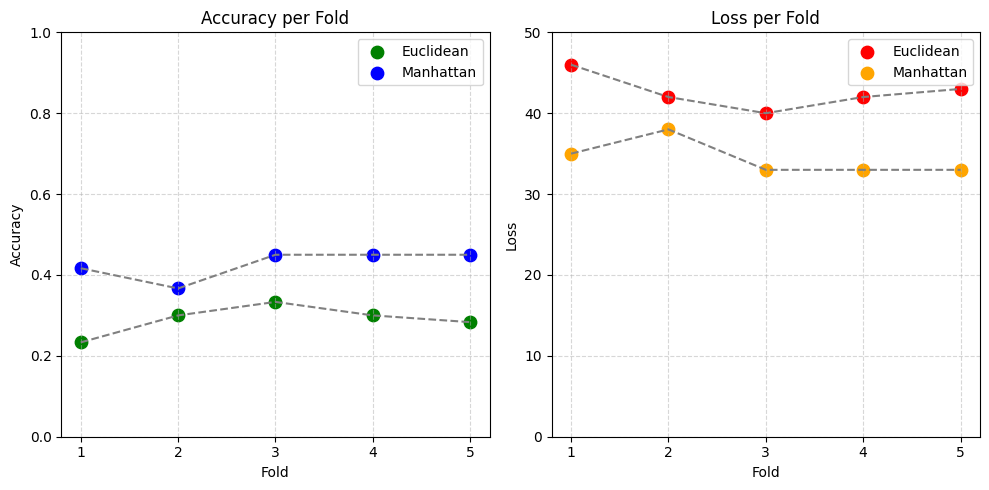

In [13]:
#ploting

plt.figure(figsize=(10,5))

# Accuracy
plt.subplot(1, 2, 1)
plt.scatter(range(1, 6), euclidean_accuracy_folds, color='green', s=80, label='Euclidean')
plt.plot(range(1, 6), euclidean_accuracy_folds, linestyle='--', color='gray')
plt.scatter(range(1, 6), manhattan_accuracy_folds, color='blue', s=80, label='Manhattan')
plt.plot(range(1, 6), manhattan_accuracy_folds, linestyle='--', color='gray')
plt.title('Accuracy per Fold')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.xticks(range(1, 6))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Loss per Fold
plt.subplot(1, 2, 2)
plt.scatter(range(1, 6), euclidean_loss_folds, color='red', s=80, label='Euclidean')
plt.plot(range(1, 6), euclidean_loss_folds, linestyle='--', color='gray')
plt.scatter(range(1, 6), manhattan_loss_folds, color='orange', s=80, label='Manhattan')
plt.plot(range(1, 6), manhattan_loss_folds, linestyle='--', color='gray')
plt.title('Loss per Fold')
plt.xlabel('Fold')
plt.ylabel('Loss')
plt.ylim(0, 50)  # 0–50
plt.xticks(range(1, 6))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

# Results and Analysis
For each fold, we will vary the hyperparameter K (the number of nearest neighbors) and record the accuracy achieved by the model
for each value of K. We will compute the average accuracy across all folds for each value of K and distance calculation technique.

Next, we will plot a graph with K on the X-axis and accuracy on the Y-axis for both the Manhattan (L1) and Euclidean (L2) distances.
This graph will allow us to visualize the impact of different values of K on the model's accuracy for each distance calculation
technique.

**Manhattan (L1) Accuracy**

* Manhattan distance consistently performs better than Euclidean.
* Accuracy stays between 0.36 and 0.45, showing stable performance across all folds.
* Peak accuracy occurs at Fold 3 and Fold 4.

**Euclidean (L2) Accuracy**

* Euclidean distance performs worse and fluctuates more.
* Accuracy ranges from 0.24 to 0.33, which is significantly lower.
* Performance slightly improves at Fold 2 and Fold 3 but drops again afterward.

**Fold 3 gives the best result for both distance metrics.**

**Manhattan (L1) Loss**

* Loss stays between 33 and 38, showing consistent, lower loss.
* Lowest loss appears in Fold 3.

**Euclidean (L2) Loss**

* Euclidean distance shows higher loss (40–46).
* Fold 1 and Fold 5 have particularly high error rates.

# Discussion

In this study, we performed gray-scale image classification using the k-Nearest Neighbors (k-NN) algorithm with two distance metrics: Manhattan (L1) and Euclidean (L2). The goal was to determine which distance metric provides better performance for classifying small (32×32), low-resolution images of three classes: cats, dogs, and pandas. To ensure a fair and reliable evaluation, we employed 5-fold cross-validation, which allowed every sample in the dataset to be used once for testing and four times for training.

The results show a clear performance difference between the two distance metrics. Manhattan (L1) consistently outperformed Euclidean (L2) across all folds. The L1 distance resulted in higher accuracies and lower losses, indicating that it made fewer classification errors. In contrast, the L2 distance showed larger fluctuations in accuracy and maintained a relatively higher loss.

Since Manhattan has lower loss, it makes fewer mistakes.
This confirms that L1 distance is better suited for this classification.